In [117]:
import csv
import sys
import time
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit.library import zz_feature_map, real_amplitudes
from qiskit_machine_learning.algorithms import VQC
from qiskit_machine_learning.optimizers import SciPyOptimizer
from qiskit_algorithms.optimizers import L_BFGS_B
from qiskit_algorithms.optimizers import COBYLA
from qiskit_algorithms.optimizers import SPSA 
from qiskit_aer import AerSimulator
from sklearn.model_selection import train_test_split

In [118]:
# ── Configuration ─────────────────────────────────────────────────────────────

# Dataset
n          = 1000    # Number of generated points
TEST_SIZE  = 0.2    # Fraction used for test set
SEED       = 1      # Random seed (data split & optimizer init)
N_DIM      = 2     # Features dimension

# Optimization
MAXITER    = 300     # minimizer max iterations
OPTIMIZER_NAME_INPUT = "L_BFGS_B"  # Ex: "SPSA", "COBYLA", "L-BFGS-B", "L_BFGS_B"
_OPT_NAME_MAP = {
    "SPSA": "SPSA",
    "COBYLA": "COBYLA",
    "L-BFGS-B": "L-BFGS-B",
    "L_BFGS_B": "L-BFGS-B",
    "LBFGSB": "L-BFGS-B",
}
OPTIMIZER_NAME = _OPT_NAME_MAP.get(OPTIMIZER_NAME_INPUT.upper(), OPTIMIZER_NAME_INPUT)

# Logging
RESULTS_DIR = Path("RESULTS")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
LOG_CSV_PATH = RESULTS_DIR / "optimizer_performance.csv"
RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_START_MONO = None

CSV_COLUMNS = [
    "run_id",
    "timestamp_local",
    "optimizer",
    "iteration",
    "cost",
    "maxiter",
    "n_dim",
    "elapsed_seconds",
]

def _upgrade_csv_schema(csv_path):
    if not csv_path.exists() or csv_path.stat().st_size == 0:
        return
    with csv_path.open("r", newline="", encoding="utf-8") as f:
        rows = list(csv.reader(f))
    if not rows:
        return
    header = rows[0]
    if "elapsed_seconds" in header:
        return
    old_rows = rows[1:]
    with csv_path.open("w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(CSV_COLUMNS)
        for row in old_rows:
            writer.writerow(row + [""] if len(row) == 7 else row)

# Create/upgrade CSV schema immediately
_upgrade_csv_schema(LOG_CSV_PATH)
if not LOG_CSV_PATH.exists() or LOG_CSV_PATH.stat().st_size == 0:
    with LOG_CSV_PATH.open("w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(CSV_COLUMNS)

print(f"Optimizer selected: {OPTIMIZER_NAME}")
# ──────────────────────────────────────────────────────────────────────────────


Optimizer selected: L-BFGS-B


In [119]:
def generate_nsphere_data(n_samples, n_dim, radius=None):
    # Génération de points entre -1 et 1
    X = np.random.uniform(-1, 1, (n_samples, n_dim))    
    # Le rayon par défaut est choisi pour équilibrer les classes
    if radius is None:
        radius = np.sqrt(n_dim / 3) 
        
    # Calcul de la norme euclidienne au carré
    dist_sq = np.sum(X**2, axis=1)
    y = (dist_sq >= radius**2).astype(int)
    
    return X, y, radius



In [120]:
X, y, R = generate_nsphere_data(n_samples=n, n_dim=N_DIM)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

print(X_train.shape, y_train.shape)

(800, 2) (800,)


## VQC

In [121]:
iteration = 0

def _ensure_csv_header(csv_path):
    if not csv_path.exists() or csv_path.stat().st_size == 0:
        with csv_path.open("w", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerow(CSV_COLUMNS)


def _append_log_row(iter_idx, cost):
    timestamp_local = datetime.now().isoformat(timespec="seconds")
    elapsed_seconds = None if RUN_START_MONO is None else round(time.perf_counter() - RUN_START_MONO, 6)

    _ensure_csv_header(LOG_CSV_PATH)
    with LOG_CSV_PATH.open("a", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow([
            RUN_ID,
            timestamp_local,
            OPTIMIZER_NAME,
            iter_idx,
            cost,
            MAXITER,
            N_DIM,
            elapsed_seconds,
        ])
        f.flush()


def _live_log(message):
    # stderr flushes more reliably in VS Code notebooks during long-running cells
    sys.stderr.write(message + "\n")
    sys.stderr.flush()


def vqc_callback(*args):
    global iteration
    iteration += 1
    cost = args[1] if len(args) > 1 else None
    _append_log_row(iteration, cost)
    _live_log(f"Iteration {iteration} | cost={cost}")


def spsa_callback(nfev, params, value, stepsize, accepted):
    global iteration
    iteration += 1
    cost = value
    _append_log_row(iteration, cost)
    _live_log(f"Iteration {iteration} | cost={cost} | nfev={nfev}")

In [122]:
feature_map = zz_feature_map(feature_dimension=N_DIM, reps=2)
ansatz = real_amplitudes(num_qubits=N_DIM, reps=2)

if OPTIMIZER_NAME == "SPSA":
    optimizer = SPSA(maxiter=MAXITER, callback=spsa_callback)
    vqc = VQC(feature_map=feature_map, ansatz=ansatz, optimizer=optimizer, callback=spsa_callback)
elif OPTIMIZER_NAME in {"COBYLA", "L-BFGS-B"}:
    optimizer = SciPyOptimizer(method=OPTIMIZER_NAME, options={"maxiter": MAXITER})
    vqc = VQC(feature_map=feature_map, ansatz=ansatz, optimizer=optimizer, callback=vqc_callback)
else:
    raise ValueError(
        f"Unsupported OPTIMIZER_NAME='{OPTIMIZER_NAME}'. Use one of: SPSA, COBYLA, L-BFGS-B"
    )

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


## Training

In [123]:
iteration = 0
RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_START_MONO = time.perf_counter()

print(f"Entraînement sur une {N_DIM}-sphère... | run_id={RUN_ID}")
vqc.fit(X_train, y_train )

Entraînement sur une 2-sphère... | run_id=20260318_113226


Iteration 1 | cost=0.9278111949882434
Iteration 2 | cost=0.8927285977842137
Iteration 3 | cost=0.8778007112662894
Iteration 4 | cost=0.8704253797899463
Iteration 5 | cost=0.8554082648857417
Iteration 6 | cost=0.8109831708489433
Iteration 7 | cost=1.1544992230636693
Iteration 8 | cost=1.4450496945563283
Iteration 9 | cost=0.80838375092782
Iteration 10 | cost=0.7895416616944098
Iteration 11 | cost=0.7371017007753409
Iteration 12 | cost=0.6923596009610195
Iteration 13 | cost=0.6788149313115934
Iteration 14 | cost=0.6738892624548342
Iteration 15 | cost=0.6732468140079675
Iteration 16 | cost=0.6728790288145591
Iteration 17 | cost=0.67293978998913
Iteration 18 | cost=0.6728808129916731
Iteration 19 | cost=0.672879122977467
Iteration 20 | cost=0.6728790339350229
Iteration 21 | cost=0.6728790339350229
Iteration 22 | cost=0.6728790339350229
Iteration 23 | cost=0.6728790339350229
Iteration 24 | cost=0.6728790339350229


## VQC Results 

In [124]:
accuracy = vqc.score(X_test, y_test)
y_pred = vqc.predict(X_test)
print(f"Précision sur le test: {accuracy*100} %")

Précision sur le test: 80.0 %


### VQC circuit

--- FEATURE MAP ---


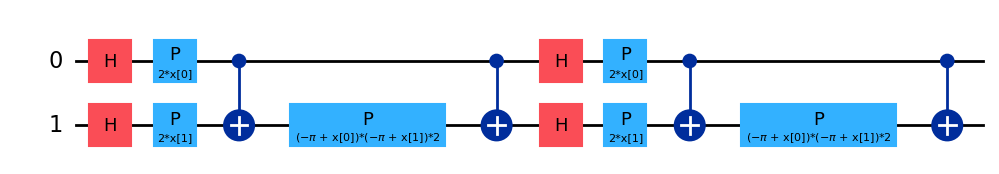

In [125]:
# 1. Visualiser comment les données N-dim sont encodées
print("--- FEATURE MAP ---")
vqc.feature_map.draw('mpl')



--- ANSATZ ---


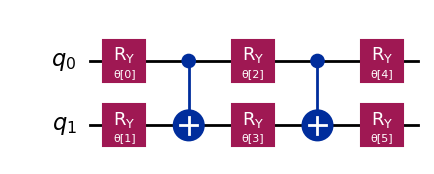

In [126]:
# 2. Visualiser la structure d'entraînement (les couches de rotation et CNOT)
print("--- ANSATZ ---")
vqc.ansatz.draw('mpl')

### Visualisation si dim=2 ou 3 

In [127]:
def plot_2d() : 
    pred1 = X_test[y_pred == 1]
    pred0 = X_test[y_pred == 0]

    plt.scatter(pred0[:,0],pred0[:,1], color = 'red', label='pred0')
    plt.scatter(pred1[:,0],pred1[:,1], color = 'blue', label='pred1')


    circle_rad = np.sqrt(N_DIM/3) # rayon par défaut, à modifier si le rayon est changé
    circle = plt.Circle((0, 0), circle_rad, color='black', fill=False, 
                        linestyle='--', linewidth=2, label='Frontière réelle')
    plt.gca().add_artist(circle)

    # Configuration du graphique
    plt.title(f"Visualisation des performances ({accuracy*100}%)")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.axhline(0, color='black', linewidth=0.5, alpha=0.5)
    plt.axvline(0, color='black', linewidth=0.5, alpha=0.5)
    plt.legend(loc='upper right')
    plt.axis('equal')
    plt.grid(True, alpha=0.3)
    plt.show()
    
def plot_3d() :
    from mpl_toolkits.mplot3d import Axes3D
 
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Masques pour séparer les résultats
    pred1 = X_test[y_pred == 1]
    pred0 = X_test[y_pred == 0]

    ax.scatter(pred0[:,0],pred0[:,1],pred0[:,2], color = 'red', label='pred0')
    ax.scatter(pred1[:,0],pred1[:,1],pred1[:,2], color = 'blue', label='pred1')
    

    # Dessiner l'enveloppe de la sphère théorique (Wireframe)
    u = np.linspace(0, 2 * np.pi, 30)
    v = np.linspace(0, np.pi, 30)
    x_sphere = R * np.outer(np.cos(u), np.sin(v))
    y_sphere = R * np.outer(np.sin(u), np.sin(v))
    z_sphere = R * np.outer(np.ones(np.size(u)), np.cos(v))
    ax.plot_wireframe(x_sphere, y_sphere, z_sphere, color="black", alpha=0.1, linewidths=0.5)

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(f"Visualisation 3D : Accuracy {accuracy*100}%")
    ax.legend()
    plt.show()

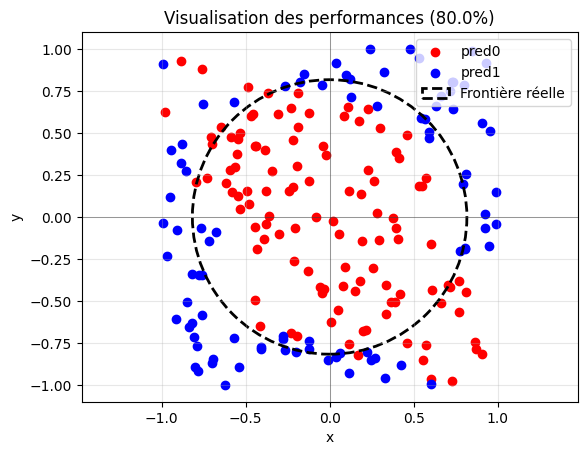

In [128]:

if N_DIM == 2 : 
    plot_2d()
    
elif N_DIM == 3 : 
    plot_3d()
    
    